# Modèle 2 — Random Forest

Le Random Forest est un ensemble d'arbres de décision entraînés sur des sous-échantillons
aléatoires des données et des features. C'est un choix naturel pour un dataset
avec des features hétérogènes (numériques + catégorielles) et des relations non linéaires.

**Avantages :** robuste, peu sensible aux valeurs aberrantes, fournit une feature importance native  
**Limites :** moins interprétable qu'une régression logistique, plus lent à entraîner

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

from src.data.loader import PROCESSED_DIR
from src.evaluation.metrics import (
    compute_classification_metrics, print_classification_report,
    plot_roc_curve, plot_confusion_matrix, plot_feature_importance
)
from src.models.mlflow_utils import setup_mlflow, log_classification_run, EXPERIMENT_CHURN

plt.rcParams['figure.dpi'] = 110

X_train = pd.read_csv(PROCESSED_DIR / 'X_train.csv')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train.csv').squeeze()
y_test = pd.read_csv(PROCESSED_DIR / 'y_test.csv').squeeze()
feature_names = joblib.load(PROCESSED_DIR / 'feature_names.joblib')

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (8000, 58) | Test : (2000, 58)


## 1. Entraînement

In [3]:
# n_estimators=200 : suffisant pour stabiliser les prédictions sans temps de calcul excessif.
# max_depth=15 : évite l'overfitting tout en capturant les interactions non linéaires.
# class_weight='balanced' : compense le déséquilibre 90/10 du churn.
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    max_features='sqrt',
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

model.fit(X_train, y_train)
print("Entraînement terminé.")

Entraînement terminé.


## 2. Évaluation

In [4]:
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = compute_classification_metrics(y_test.values, y_pred, y_proba)
print_classification_report(y_test, y_pred, 'Random Forest')

print("\nMétriques :")
for k, v in metrics.items():
    print(f"  {k} : {v:.4f}")


Rapport de classification — Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

   Non-Churn       0.91      0.97      0.94      1796
       Churn       0.40      0.21      0.27       204

    accuracy                           0.89      2000
   macro avg       0.66      0.59      0.61      2000
weighted avg       0.86      0.89      0.87      2000


Métriques :
  accuracy : 0.8880
  auc_roc : 0.8093
  f1_weighted : 0.8713
  f1_churn : 0.2727
  precision_churn : 0.4038
  recall_churn : 0.2059
  log_loss : 0.3376


In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(model, X_train, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
print(f"AUC-ROC CV (5 plis) : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")

AUC-ROC CV (5 plis) : 0.8003 ± 0.0153


## 3. Visualisations

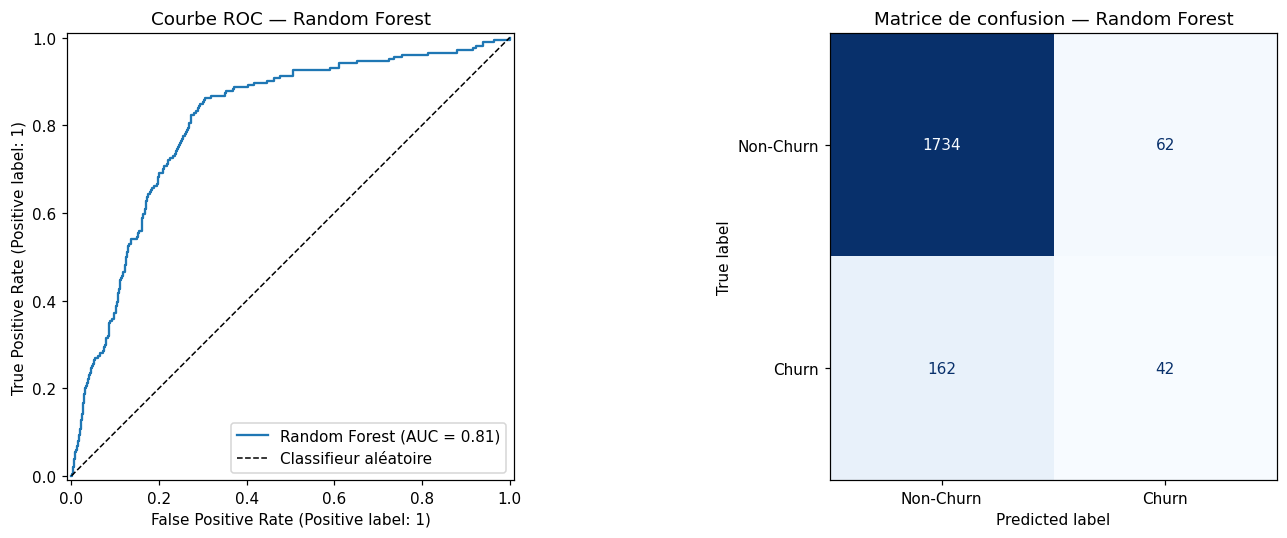

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_roc_curve(model, X_test, y_test, 'Random Forest', ax=axes[0])
plot_confusion_matrix(y_test, y_pred, 'Random Forest', ax=axes[1])
plt.tight_layout()
plt.savefig('../data/processed/fig_rf_roc_cm.png', bbox_inches='tight')
plt.show()

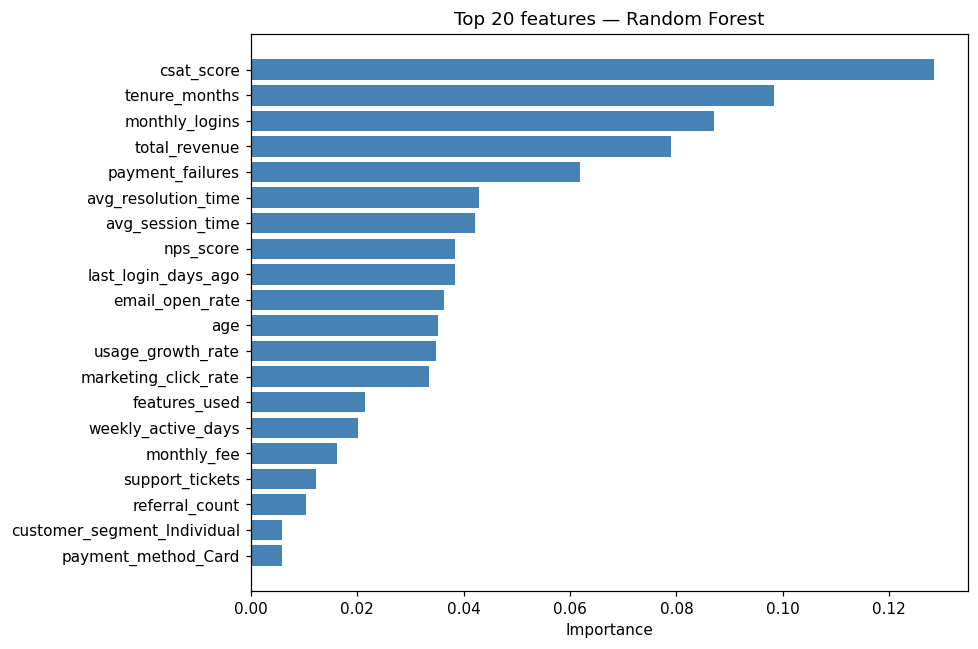

In [7]:
# La feature importance du Random Forest est calculée comme la réduction
# moyenne de l'impureté de Gini à travers tous les arbres — plus fiable
# que les coefficients d'une régression logistique pour des données mixtes.
fig = plot_feature_importance(
    model.feature_importances_, feature_names, 'Random Forest', top_n=20
)
plt.savefig('../data/processed/fig_rf_importance.png', bbox_inches='tight')
plt.show()

## 4. Enregistrement MLflow

In [8]:
setup_mlflow(EXPERIMENT_CHURN)

params = {
    'n_estimators': model.n_estimators,
    'max_depth': model.max_depth,
    'min_samples_leaf': model.min_samples_leaf,
    'max_features': model.max_features,
    'class_weight': 'balanced',
    'cv_auc_mean': float(cv_auc.mean()),
    'cv_auc_std': float(cv_auc.std()),
}

run_id = log_classification_run(
    model=model,
    model_name='Random Forest',
    params=params,
    metrics=metrics,
    X_train=X_train,
    X_test=X_test,
    y_test=y_test,
    feature_names=feature_names,
)

joblib.dump(model, PROCESSED_DIR / 'model_random_forest.joblib')
print(f"Run MLflow : {run_id}")

Expérience MLflow : 'churn_classification' (id=1)
Run enregistré : Random Forest | run_id=e779376115534129b5bf38d6ac212c91
  AUC-ROC : 0.8093
  F1 (classe 1) : 0.2727
🏃 View run Random Forest at: http://localhost:5000/#/experiments/1/runs/e779376115534129b5bf38d6ac212c91
🧪 View experiment at: http://localhost:5000/#/experiments/1
Run MLflow : e779376115534129b5bf38d6ac212c91


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist_rf = {
    'n_estimators': randint(100, 400),
    'max_depth': randint(8, 25),
    'min_samples_leaf': randint(2, 15),
    'max_features': ['sqrt', 'log2', 0.5],
}

base_rf = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
)

cv_strat = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

search_rf = RandomizedSearchCV(
    base_rf,
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='roc_auc',
    cv=cv_strat,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)

search_rf.fit(X_train, y_train)

print("Meilleurs hyperparametres :")
for k, v in search_rf.best_params_.items():
    print(f"  {k} : {v}")
print(f"\nMeilleur AUC-ROC CV (3 plis) : {search_rf.best_score_:.4f}")

best_rf = search_rf.best_estimator_
y_pred_rf_opt = best_rf.predict(X_test)
y_proba_rf_opt = best_rf.predict_proba(X_test)[:, 1]
metrics_rf_opt = compute_classification_metrics(y_test.values, y_pred_rf_opt, y_proba_rf_opt)

print(f"\nAUC-ROC test (modele optimise) : {metrics_rf_opt['auc_roc']:.4f}")
print(f"AUC-ROC test (modele de base)   : {metrics['auc_roc']:.4f}")
print(f"Gain : {metrics_rf_opt['auc_roc'] - metrics['auc_roc']:+.4f}")

## 5. Recherche d'hyperparametres — RandomizedSearchCV

Le Random Forest a plusieurs hyperparametres importants a regler ensemble :
le nombre d'arbres, la profondeur maximale et le nombre minimum de samples par feuille.
Une recherche aleatoire est plus efficace qu'une grille complete ici.